# 📊 Project 2: Data Classification Using AI
**DecodeLab Internship Project**

**Goal:** Build a basic classification model using a small dataset.

**Key Skills:** Data handling, supervised learning basics, model training

---

## 📌 What is Classification?
Classification is a **supervised machine learning** task where we train a model to predict which category (class) a data point belongs to. Example: Predicting if an order will be **Delivered** or **Cancelled** based on order data.

## Step 1: Install & Import Libraries

In [2]:
# All libraries are pre-installed in Google Colab ✅
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [14]:
from sklearn.ensemble import RandomForestClassifier

## Step 2: Load and Understand the Dataset

> 📁 **Upload your `Dataset_for_Data_Analytics.xlsx` file** using the file upload button on the left panel in Colab, OR use the cell below to upload it.

In [3]:
# ----- OPTION A: Upload the file in Colab -----
from google.colab import files
uploaded = files.upload()  # Click and select your .xlsx file

# Load the uploaded file
df = pd.read_excel(list(uploaded.keys())[0])
print("✅ Dataset loaded from upload!")

Saving Dataset for Data Analytics.xlsx to Dataset for Data Analytics (1).xlsx
✅ Dataset loaded from upload!


In [16]:

# df = pd.read_excel('Dataset_for_Data_Analytics.xlsx')

# ---- Explore the dataset ----
print("📐 Shape:", df.shape)
print("\n📋 Columns:", df.columns.tolist())
print("\n🔍 First 5 rows:")
df.head()

📐 Shape: (1200, 14)

📋 Columns: ['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

🔍 First 5 rows:


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [5]:
# Check data types and missing values
print("📊 Data Types:")
print(df.dtypes)
print("\n❓ Missing Values:")
print(df.isnull().sum())

📊 Data Types:
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object

❓ Missing Values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


🎯 Target Column (OrderStatus) Distribution:
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


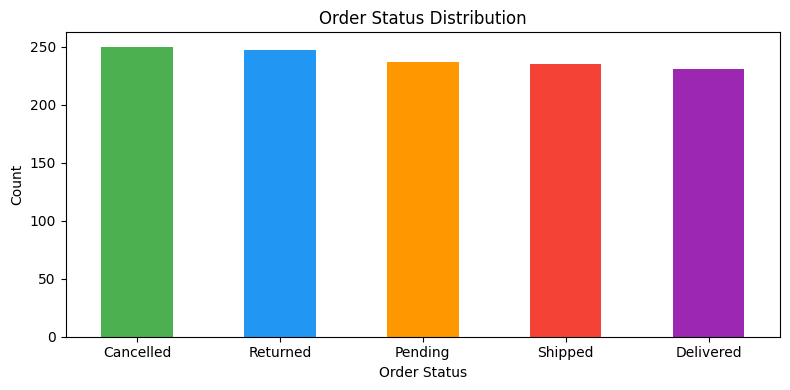

In [6]:
# See what we are predicting — the OrderStatus distribution
print("🎯 Target Column (OrderStatus) Distribution:")
print(df['OrderStatus'].value_counts())

plt.figure(figsize=(8, 4))
df['OrderStatus'].value_counts().plot(kind='bar', color=['#4CAF50','#2196F3','#FF9800','#F44336','#9C27B0'])
plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 3: Data Preprocessing

In [7]:
# Select features for classification
# We use: Product, Quantity, UnitPrice, PaymentMethod, TotalPrice
# Target: OrderStatus

features = ['Product', 'Quantity', 'UnitPrice', 'PaymentMethod', 'TotalPrice', 'ItemsInCart']
target = 'OrderStatus'

# Drop rows with missing values in selected columns
data = df[features + [target]].dropna()
print(f"✅ Data shape after dropping nulls: {data.shape}")

# Encode categorical columns using LabelEncoder
le = LabelEncoder()

data = data.copy()
data['Product_enc']       = le.fit_transform(data['Product'])
data['PaymentMethod_enc'] = le.fit_transform(data['PaymentMethod'])
data['OrderStatus_enc']   = le.fit_transform(data['OrderStatus'])

# Print the label mapping for OrderStatus
status_classes = le.classes_
print("\n🏷️ OrderStatus Label Encoding:")
for i, cls in enumerate(status_classes):
    print(f"  {i} → {cls}")

✅ Data shape after dropping nulls: (1200, 7)

🏷️ OrderStatus Label Encoding:
  0 → Cancelled
  1 → Delivered
  2 → Pending
  3 → Returned
  4 → Shipped


## Step 4: Split Data into Training and Testing Sets

In [8]:
# Define X (features) and y (target)
X = data[['Product_enc', 'Quantity', 'UnitPrice', 'PaymentMethod_enc', 'TotalPrice', 'ItemsInCart']]
y = data['OrderStatus_enc']

# 80% training, 20% testing — standard split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Training samples : {X_train.shape[0]}")
print(f"✅ Testing  samples : {X_test.shape[0]}")

✅ Training samples : 960
✅ Testing  samples : 240


## Step 5: Train a Classification Model (Decision Tree)

In [9]:
# Decision Tree Classifier — simple and interpretable
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

print("✅ Model trained successfully!")
print(f"📈 Training Accuracy: {model.score(X_train, y_train)*100:.2f}%")

✅ Model trained successfully!
📈 Training Accuracy: 27.50%


## Step 6: Evaluate the Model

In [10]:
# Predictions on test set
y_pred = model.predict(X_test)

# Accuracy Score
acc = accuracy_score(y_test, y_pred)
print(f"🎯 Test Accuracy: {acc*100:.2f}%")

# Classification Report
print("\n📄 Classification Report:")
print(classification_report(y_test, y_pred, target_names=status_classes))

🎯 Test Accuracy: 15.42%

📄 Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.16      0.05      0.08        59
   Delivered       0.15      0.61      0.23        41
     Pending       0.08      0.03      0.04        40
    Returned       0.21      0.16      0.18        43
     Shipped       0.50      0.02      0.03        57

    accuracy                           0.15       240
   macro avg       0.22      0.17      0.11       240
weighted avg       0.23      0.15      0.11       240



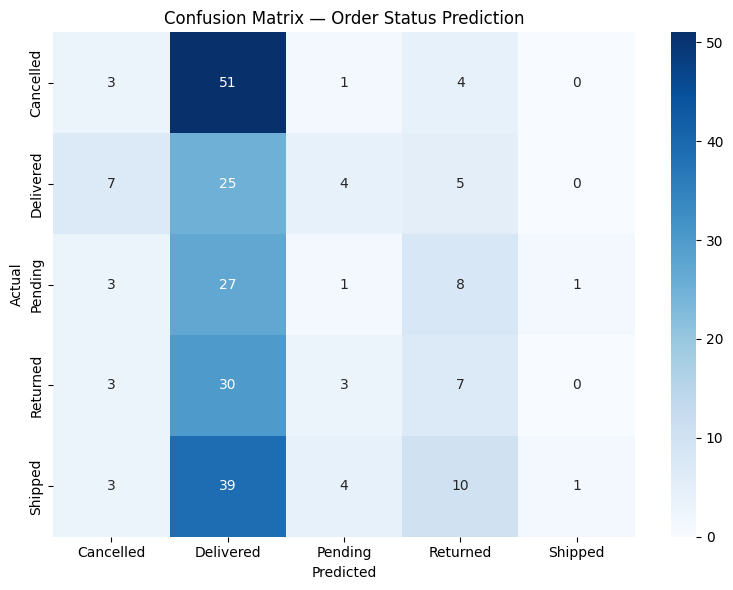

In [11]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=status_classes,
            yticklabels=status_classes)
plt.title('Confusion Matrix — Order Status Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

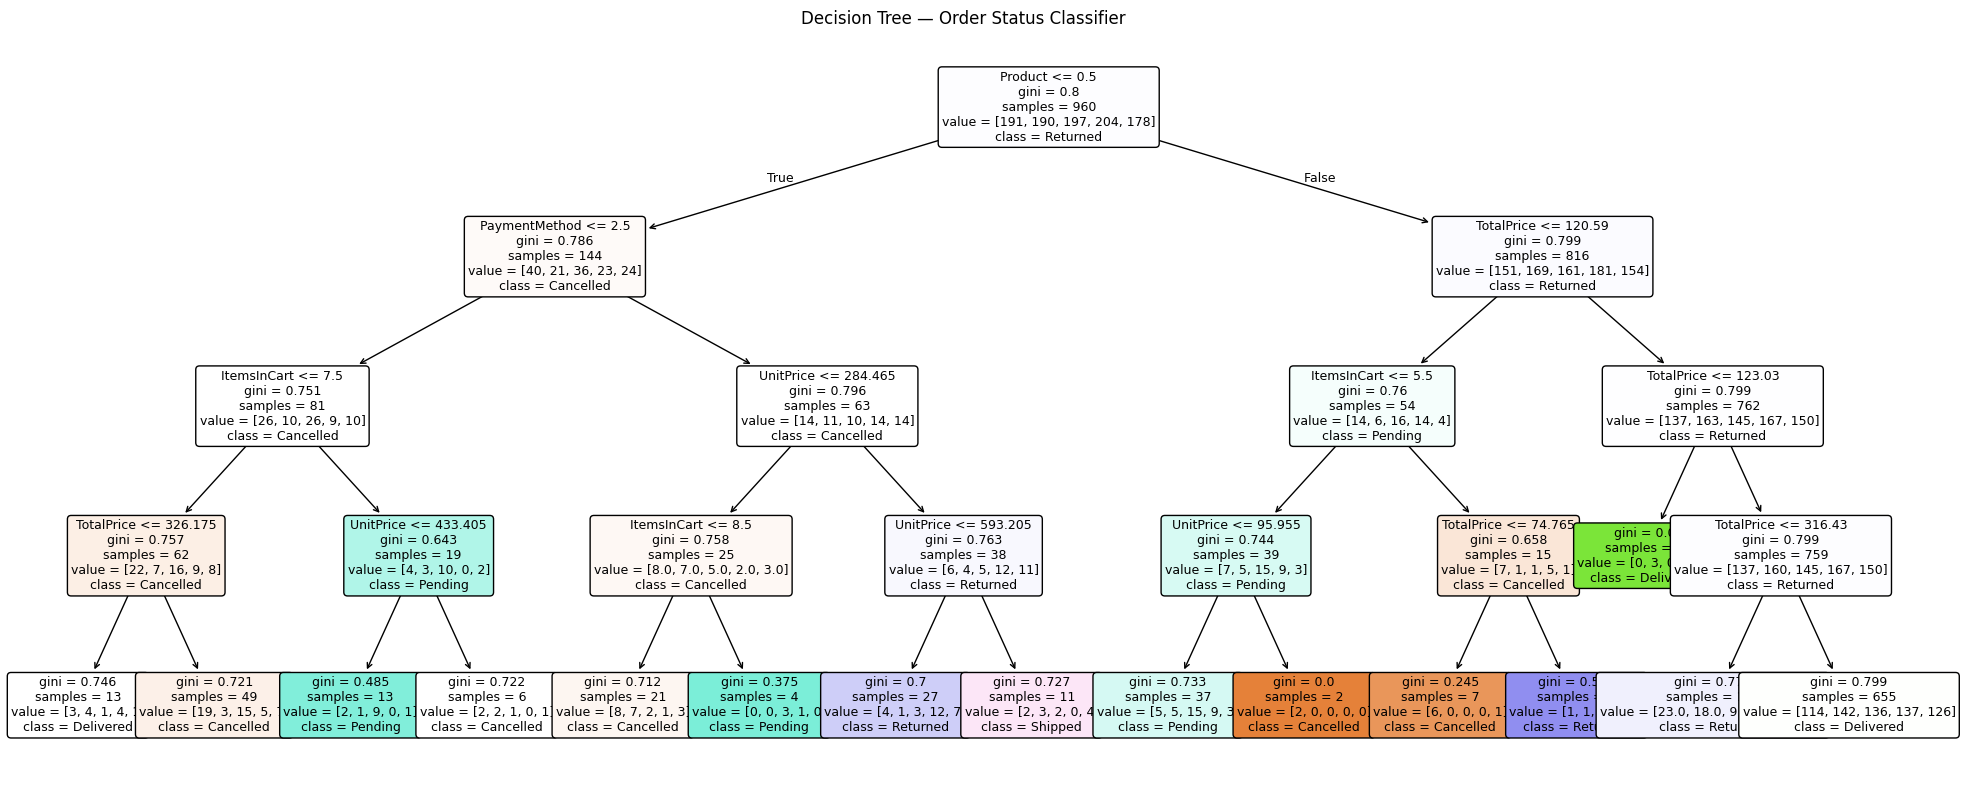

In [12]:
# Visualize the Decision Tree
plt.figure(figsize=(20, 8))
plot_tree(model,
          feature_names=['Product', 'Quantity', 'UnitPrice', 'PaymentMethod', 'TotalPrice', 'ItemsInCart'],
          class_names=status_classes,
          filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree — Order Status Classifier')
plt.tight_layout()
plt.show()

## Step 7: Train Another Classification Model (RandomForestClassifier)

✅ Random Forest Model trained successfully!
📈 Training Accuracy: 100.00%

🎯 Random Forest Test Accuracy: 17.08%

📄 Random Forest Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.22      0.19      0.20        59
   Delivered       0.19      0.20      0.19        41
     Pending       0.08      0.10      0.09        40
    Returned       0.15      0.23      0.19        43
     Shipped       0.26      0.14      0.18        57

    accuracy                           0.17       240
   macro avg       0.18      0.17      0.17       240
weighted avg       0.19      0.17      0.17       240



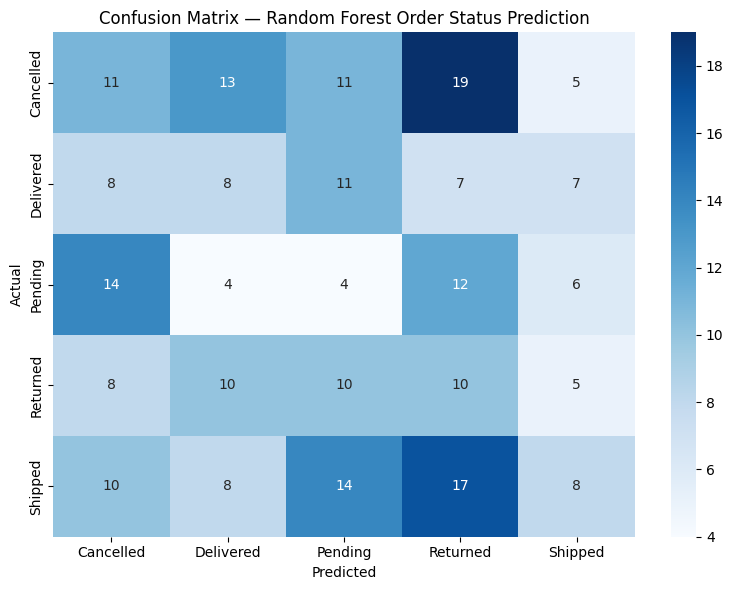

In [15]:
# Initialize and train a RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("✅ Random Forest Model trained successfully!")
print(f"📈 Training Accuracy: {rf_model.score(X_train, y_train)*100:.2f}%")

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the Random Forest Model
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"\n🎯 Random Forest Test Accuracy: {acc_rf*100:.2f}%")

print("\n📄 Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=status_classes))

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=status_classes,
            yticklabels=status_classes)
plt.title('Confusion Matrix — Random Forest Order Status Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Step 8: Predict on New Data

In [13]:
# Predict a new order's status
# Format: [Product_enc, Quantity, UnitPrice, PaymentMethod_enc, TotalPrice, ItemsInCart]
# You need to manually encode categorical values as per the LabelEncoder above

# Example: Laptop(2), Qty=2, Price=500, CreditCard(1), Total=1000, Cart=3
new_order = [[2, 2, 500.0, 1, 1000.0, 3]]

prediction_encoded = model.predict(new_order)[0]
predicted_status = status_classes[prediction_encoded]

print(f"🔮 Predicted Order Status: {predicted_status}")

🔮 Predicted Order Status: Delivered


## Step 9: Resources

---
## ✅ Summary
| Step | Action |
|---|---|
| 1 | Loaded the e-commerce dataset |
| 2 | Explored and understood the data |
| 3 | Encoded categorical features |
| 4 | Split into 80% train / 20% test |
| 5 | Trained a Decision Tree Classifier |
| 6 | Evaluated with accuracy + confusion matrix |
| 7 | Trained a Random Forest Classifier |
| 8 | Made predictions on new orders |

---
**🎓 DecodeLab Internship — Project 2 Complete!**